## Cross-Platform Latent Connectivity Detection using the Temporal Dimension

### Social Media Usecase

Not all connections between individuals are apparent in the structural network data we have access to. One example to such scenario is when individuals employ different platforms of communications, which inherently lack inter-platform connections.

In this demo, we demonstrate the ability to match profiles across separate platforms, despite the absence of explicit connections between them.
We introduce the concept of an individual's *temporal fingerprint*, defined by the time gaps between consecutive activities (inter-event time distribution), and find that profiles belonging to the same individual or organization present similar temporal fingerprints across different social domains.

This methodology uses merely the temporal metadata of users' activity, and does not require access to network structure or user generated content. As such, it can be employed on any type of temporal dataset, including encrypted domains.

**Overview**
1. Loading the data
2. Preprocessing
3. Computing the KS distance
4. Analysis & Evaluation

**Files:**
1. hashed_identity_matching_demo_20240608_20240615.csv: raw metadata of posting activity


**Data Labeling**

We manually generated the ground truth labels for this dataset, relying on profile name similarity (for instance "foo_networks" on Twitter and "FooNetworks" on Telegram), profile biographies, official websites, and other public sources of information (articles, Linktree) that indicate affiliation with the same individual or organization. The experiment on this dataset involved analyzing eight weekly activity snapshots of these users from all three social platforms. Each snapshot contains merely temporal data in the form of individual posting times, and lacks network data in the form of retweets, re-posts, likes and other connections.


Examples of possible identity groups in the dataset:
1. [(@company1, twitter), (@company1, telegram)]
2. [(@individual1, instagram), (@individual1, telegram), (@individual1, twitter)]

**Data Disclaimer**

The data was scraped and provided by a third party and carefully tagged using the guidelines above.

**Citation**

If you find our work useful, please kindly consider citing the original paper: https://arxiv.org/pdf/2407.04350

### Loading the Data

The dataset includes posting activity metadata collected over the span of 18 days from various social media platforms such as twitter (X), telegram, and instagram. The schema:
- "creator_name" (string): encryped name of the profile that posted 
- "platform_type" (string): the social platform to which the profile belongs
- "creation_time" (string): the date and time at which the post was created, in the format of %Y-%m-%d %H:%M:%S
- "label": unique identity the user belongs to

*Important Note: a 'user' is defined as a unique pair of "creator_name" and "platform_type," e.g., ('FooNetworks', 'twitter').*

In [1]:
import pandas as pd
from scipy.stats import ks_2samp
from typing import List
import matplotlib.pyplot as plt

In [2]:
# load the post metadata from time period: ["2024-06-08", "2024-06-15")
posts_df = pd.read_csv("hashed_identity_matching_demo_20240608_20240615.csv", index_col=0)

# save column names as constants
PROFILE_COL_NAME, PLATFORMS_COL_NAME, CREATION_TIMES_COL_NAME, LABEL_COL = posts_df.columns

posts_df

,creator_name,platform_type,creation_time,label
0,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:18:01+00:00,198.0
1,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:19:13+00:00,198.0
2,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:22:42+00:00,198.0
3,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:24:14+00:00,198.0
4,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:25:46+00:00,198.0
...,...,...,...,...
84781,0ea9c17745d25ad2ac38eca26013d45e1455a436e6cf01...,twitter,2024-06-14 13:09:00+00:00,217.0
84782,0ea9c17745d25ad2ac38eca26013d45e1455a436e6cf01...,twitter,2024-06-14 13:37:44+00:00,217.0
84783,0ea9c17745d25ad2ac38eca26013d45e1455a436e6cf01...,twitter,2024-06-14 13:37:45+00:00,217.0
84784,0ea9c17745d25ad2ac38eca26013d45e1455a436e6cf01...,twitter,2024-06-14 15:48:00+00:00,217.0


### Preprocessing

To extract communities from the data, we'll first need to establish and evaluate the relationship between each pair of users.

That includes a few simple steps:

1. Type casting
2. Computing the silence periods per user
3. (optional) filtering based on minimum activity

In [3]:
# Convert string timestamps into datetime type
posts_df[CREATION_TIMES_COL_NAME] = pd.to_datetime(posts_df[CREATION_TIMES_COL_NAME])

# cast labels to from float to int type
posts_df[LABEL_COL] = posts_df[LABEL_COL].astype(int)

posts_df.head()

,creator_name,platform_type,creation_time,label
0,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:18:01+00:00,198
1,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:19:13+00:00,198
2,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:22:42+00:00,198
3,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:24:14+00:00,198
4,ce6375aa4595a6c7459e9ad10a9368a5a551079dff300e...,twitter,2024-06-08 00:25:46+00:00,198


#### Computing Silence Periods

A silence period is a period of time that elapsed between two consecutive events. In our case, we will define it as the time, in seconds between each posts by the same user.

*(Note: Since we later plot the silence period distributions on a log-log scale, we add a precautionary 1 second to all silence periods to avoid a log(0) value)*

In [4]:
# sort posting times per user
posts_df = posts_df.sort_values([PROFILE_COL_NAME, PLATFORMS_COL_NAME, CREATION_TIMES_COL_NAME])

def aggregate_and_compute_silence_periods(user_data: pd.DataFrame) -> pd.Series:
    """Compute inter-event periods and group information per user"""
    
    silence_periods = user_data[CREATION_TIMES_COL_NAME].diff().dt.total_seconds().add(1).dropna().tolist()
    creation_times = user_data[CREATION_TIMES_COL_NAME].tolist()
    label = user_data['label'].tolist()[0]

    return pd.Series([creation_times, silence_periods, label])

grouped_df = posts_df.groupby([PROFILE_COL_NAME, PLATFORMS_COL_NAME]).apply(aggregate_and_compute_silence_periods)
grouped_df.columns = ["creation_times", "silence_periods", "label"]

grouped_df.head(5)

,,creation_times,silence_periods,label
creator_name,platform_type,,,
005b44f3e5e9fbd53872e27f8315dfbed58c48c96ca92d2cc800531870ac277e,telegram,"[2024-06-08 03:30:04+00:00, 2024-06-08 03:30:3...","[33.0, 167356.0, 30.0, 37.0, 1731.0, 385.0, 11...",85
01276766f196152b05ed337916f7b516d6338283af1d88d535d4aba2259d28cf,twitter,"[2024-06-08 11:55:17+00:00, 2024-06-08 12:00:4...","[330.0, 2.0, 342.0, 2.0, 1163.0, 299.0, 2.0, 8...",214
022f5e4ab56c8b2b88405dced20756e1ac10b3200e93da0592329e8dc4ae1a2a,twitter,"[2024-06-08 00:08:22+00:00, 2024-06-08 00:35:3...","[1637.0, 761.0, 633.0, 620.0, 183.0, 388.0, 48...",0
06866fbc6b3463288eb87ceee24e6aa964f6b451b1ab9a7da0ecaa959d13158f,twitter,"[2024-06-08 04:40:44+00:00, 2024-06-08 04:53:3...","[775.0, 187.0, 21589.0, 2.0, 2.0, 2.0, 2.0, 2....",199
07664a566d363b22529e2c17ff8656653a1676d2c87d926e870ce7b7c053a435,telegram,"[2024-06-08 07:58:34+00:00, 2024-06-08 11:08:0...","[11370.0, 8696.0, 12879.0, 10589.0, 43373.0, 1...",89


In [5]:
# [Optional] Filter users based on minimum activity. In our case, at least 20 posts in the given time period.
MINIMUM_ACTIVITY = 20
grouped_df = grouped_df[grouped_df["creation_times"].apply(len) >= MINIMUM_ACTIVITY]
grouped_df

,,creation_times,silence_periods,label
creator_name,platform_type,,,
005b44f3e5e9fbd53872e27f8315dfbed58c48c96ca92d2cc800531870ac277e,telegram,"[2024-06-08 03:30:04+00:00, 2024-06-08 03:30:3...","[33.0, 167356.0, 30.0, 37.0, 1731.0, 385.0, 11...",85
01276766f196152b05ed337916f7b516d6338283af1d88d535d4aba2259d28cf,twitter,"[2024-06-08 11:55:17+00:00, 2024-06-08 12:00:4...","[330.0, 2.0, 342.0, 2.0, 1163.0, 299.0, 2.0, 8...",214
022f5e4ab56c8b2b88405dced20756e1ac10b3200e93da0592329e8dc4ae1a2a,twitter,"[2024-06-08 00:08:22+00:00, 2024-06-08 00:35:3...","[1637.0, 761.0, 633.0, 620.0, 183.0, 388.0, 48...",0
06866fbc6b3463288eb87ceee24e6aa964f6b451b1ab9a7da0ecaa959d13158f,twitter,"[2024-06-08 04:40:44+00:00, 2024-06-08 04:53:3...","[775.0, 187.0, 21589.0, 2.0, 2.0, 2.0, 2.0, 2....",199
07664a566d363b22529e2c17ff8656653a1676d2c87d926e870ce7b7c053a435,telegram,"[2024-06-08 07:58:34+00:00, 2024-06-08 11:08:0...","[11370.0, 8696.0, 12879.0, 10589.0, 43373.0, 1...",89
...,...,...,...,...
fcf1682c7a7b83b0437d6e15371e72781a973f7f2b65f4a1fc4ea1137e055441,telegram,"[2024-06-08 07:05:12+00:00, 2024-06-08 09:34:5...","[8979.0, 2.0, 592.0, 2.0, 2.0, 319.0, 2.0, 2.0...",124
fd09dc97b3ef10b9a00031334a5ee92c69fbdc121041d779ce7a75d2289b513b,twitter,"[2024-06-08 14:03:07+00:00, 2024-06-10 10:30:0...","[160014.0, 53454.0, 3570.0, 53.0, 10872.0, 113...",94
fe818db5dbb81bf491ab23632ff0e9cb1543dabb43be4b5e75dfce9a2c63e902,telegram,"[2024-06-08 03:38:14+00:00, 2024-06-08 12:51:5...","[33226.0, 45720.0, 78565.0, 2.0, 50353.0, 1331...",50


#### Computing the KS (Kolmogorov–Smirnov) distance

The [Kolmogorov–Smirnov test](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test) is a nonparametric test for determining whether two samples of data came from the same distribution, or in the other words, the likelihood of observing the two samples of data given that they were drawn from the same probability distribution.

The outcome (statistic) of the test is the maximum distance per value observed between the two provided empirical distributions:

<img src="ks-statistic-illustration.png" alt="KS statistic illustration" style="width: 200px;"/>

We will employ this test to evaluate the similarity between the inter-event time distributions of every pair of users, where lower KS values indicate closer distributions. Our hypothesis is that community members will have similar inter-event time distributions.

Notes:
1. For large datasets, we recommend using a parallelized framework like Spark instead of pandas
2. For the sake of simplicity, we use the function `scipy.stats.ks_2samp` here, which sorts its arguments every time. For much faster performance, we recommend pre-sorting and indexing the silence periods of each user, and modifying the function to pull pre-sorted silence periods instead of sorting in place.

In [6]:
N = len(grouped_df)
ks_results = []

# compare every cross-platform pair of users (u, v), skipping symmetrical and self-comparisons
for i in range(N):
    for j in range(i+1, N):
        # extract user info
        user1 = grouped_df.iloc[i]
        username1, platform1 = user1.name

        user2 = grouped_df.iloc[j]
        username2, platform2 = user2.name

        # only compare cross-platform pairs
        if platform1 == platform2:
            continue

        # get silence periods
        sp1 = user1.silence_periods
        sp2 = user2.silence_periods
        
        # compute the KS statistic
        ks, _ = ks_2samp(sp1, sp2)
        ks_results.append((username1, platform1, username2, platform2, float(ks), user1.label == user2.label))

ks_results = pd.DataFrame(
    ks_results,
    columns=[
        PROFILE_COL_NAME + "_1",
        PLATFORMS_COL_NAME + "_1",
        PROFILE_COL_NAME + "_2",
        PLATFORMS_COL_NAME + "_2",
        "ks",
        "correct"
    ]
)
ks_results = ks_results.sort_values('ks')
ks_results

,creator_name_1,platform_type_1,creator_name_2,platform_type_2,ks,correct
2115,175d885203a019baa12ff49533e3f8e38ed553d2f1f04d...,telegram,175d885203a019baa12ff49533e3f8e38ed553d2f1f04d...,twitter,0.027248,True
5709,4692a26cb557b1c0bd78d7d236870df91f7a5608185043...,telegram,e0059fcd95196f355fd6398ef31fdde62db948926c8a73...,twitter,0.032907,False
14459,cd7c197552a5c705cf44fbd9fa07e89a9c35660988daec...,telegram,cd7c197552a5c705cf44fbd9fa07e89a9c35660988daec...,twitter,0.038910,True
276,022f5e4ab56c8b2b88405dced20756e1ac10b3200e93da...,twitter,5a5acda11072c0d5b9abc18dd476c56bac52e0ef712bca...,telegram,0.039590,True
14129,c254ff70dd51e6a0b3c117a631a30a23ba2f7a56a81872...,telegram,e7430e901370dfe1261df560c6a25570a228eeeb7df067...,twitter,0.039731,True
...,...,...,...,...,...,...
11271,8b7252b2ab5181a3b38f27d2cb27466023c1a0ba48e855...,twitter,f222e6c288d55cc8106734c5c6ee30be7184606a3e3f8c...,telegram,0.992765,False
4100,2ca43cf2ce7234bb91089e772391d93f22077b22b12039...,twitter,f222e6c288d55cc8106734c5c6ee30be7184606a3e3f8c...,telegram,0.992903,False
9501,72c00442e0e63731b964fc23f3ee63991f022cb074b3e9...,twitter,f222e6c288d55cc8106734c5c6ee30be7184606a3e3f8c...,telegram,0.993572,False
363,022f5e4ab56c8b2b88405dced20756e1ac10b3200e93da...,twitter,f222e6c288d55cc8106734c5c6ee30be7184606a3e3f8c...,telegram,0.997860,False


### Analysis & Evaluation

Now that we have computed the KS-distance for every pair of users, let's evaluate the performance of the model.

We will do so by computing the model's accuracy on the top `k` pairs, sorted by KS score, for a wide range of `k` values.




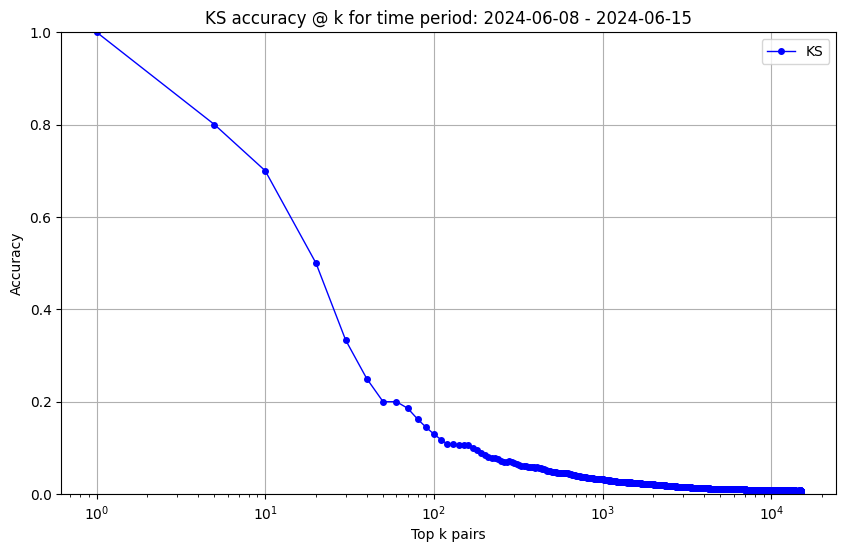

In [7]:
from typing import Iterable

def compute_accuracy_at_k(sorted_results: pd.DataFrame, k_values: Iterable[int]) -> List[float]:
    # Calculate accuracy @ k for k in range(0, N, 10)
    accuracies = []

    for k in k_values:
        top_k_pairs = sorted_results.iloc[:k]
        accuracy = top_k_pairs['correct'].mean()
        accuracies.append(accuracy)
    return accuracies


def plot_accuracy_at_k(
    results_df: pd.DataFrame,
    score_col: str = "ks",
    model_name: str = "",
    time_period: str = "",
):

    # Sort results by ks score in descending order
    sorted_results = results_df.sort_values(score_col)

    # Calculate accuracy @ k for k in [1, 5, 10, 20, 30, ..., N]
    k_values = list([1, 5] + list(range(10, len(results_df), 10)))
    accuracies = compute_accuracy_at_k(sorted_results, k_values)

    plt.figure(figsize=(10, 6))
    plt.plot(k_values, accuracies, color='blue', marker='o', markersize=4, linestyle='-', linewidth=1, label=model_name)

    plt.xlabel('Top k pairs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} accuracy @ k for time period: {time_period}')
    plt.xscale("log")
    plt.grid(True)
    plt.ylim(0, 1)

    plt.legend()
    plt.show()

plot_accuracy_at_k(ks_results, model_name="KS", time_period="2024-06-08 - 2024-06-15")